This notebooks aims to produce a figure. Specifically, in the original FT-LLM/RAG systems we evaluate only on 53/306 NACE classes, since 
they are the only frequent ones across the dataset and make up 63.3% of the total business entries. We aim to demonstrate this with a figure.

## **Import & Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re

In [2]:
interaction_matrix_path = "../data/interaction_matrix_raw.parquet"
inference_path = "../../07. Approach - Fine Tuning/1. Fine-Tuning - Inference Datasets Creation/3. Fine-Tuning - Inference Data Creation/Extracted Files/inference_dataset.jsonl"
output_path = "../results/class_support_distribution.png"

In [3]:
interaction_matrix = pd.read_parquet(interaction_matrix_path)
businesses_per_class = interaction_matrix.sum(axis=1)

evaluated_nace_codes = set()
with open(inference_path) as inference_file:
    for line in inference_file:
        record = json.loads(line)
        nace_match = re.search(r"NACE\s+(\d+\.\d+)", record["completion"])
        if nace_match:
            evaluated_nace_codes.add(round(float(nace_match.group(1)), 4))

## **Evaluate Number of Business Entries per NACE Class**

In [4]:
# Create bucket classes by support, split evaluated vs not
support_frame = pd.DataFrame({"support": businesses_per_class})
support_frame["nace_key"] = [round(float(code), 4) for code in support_frame.index]
support_frame["evaluated"] = support_frame["nace_key"].isin(evaluated_nace_codes)

range_edges = [0, 1, 2, 4, 9, 19, 49, 99, np.inf]
range_labels = ["1", "2", "3–4", "5–9", "10–19", "20–49", "50–99", "100+"]
support_frame["range"] = pd.cut(support_frame["support"], bins=range_edges, labels=range_labels)

evaluated_counts = support_frame[support_frame["evaluated"]].groupby("range", observed=False).size().reindex(range_labels).fillna(0)
other_counts = support_frame[~support_frame["evaluated"]].groupby("range", observed=False).size().reindex(range_labels).fillna(0)

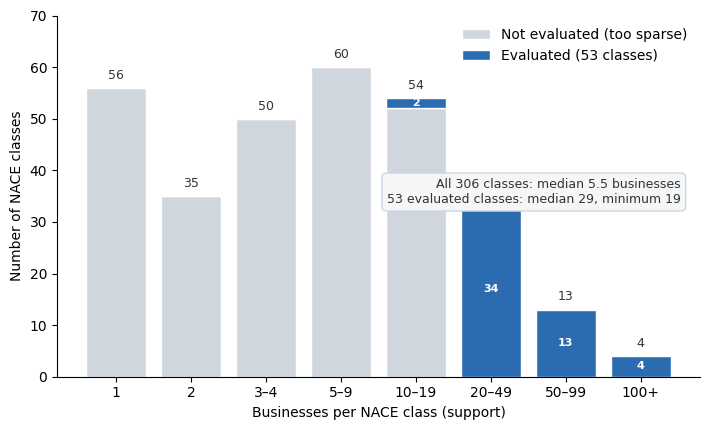

In [5]:
# Create the figure:
figure, axis = plt.subplots(figsize=(7.2, 4.4))
x_positions = np.arange(len(range_labels))

axis.bar(x_positions, other_counts.values, color="#cfd6dd", edgecolor="white", label="Not evaluated (too sparse)")
axis.bar(x_positions, evaluated_counts.values, bottom=other_counts.values, color="#2b6cb0", edgecolor="white", label=f"Evaluated ({int(evaluated_counts.sum())} classes)")

total_counts = other_counts.values + evaluated_counts.values
for position, total, evaluated_value in zip(x_positions, total_counts, evaluated_counts.values):
    axis.text(position, total + 1.2, str(int(total)), ha="center", va="bottom", fontsize=9, color="#333333")
    if evaluated_value > 0:
        axis.text(position, total - evaluated_value / 2, str(int(evaluated_value)), ha="center", va="center", fontsize=8, color="white", fontweight="bold")

axis.set_xticks(x_positions)
axis.set_xticklabels(range_labels)
axis.set_xlabel("Businesses per NACE class (support)")
axis.set_ylabel("Number of NACE classes")
axis.set_ylim(0, max(total_counts) + 10)
axis.legend(frameon=False, loc="upper right")
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

median_all = float(businesses_per_class.median())
evaluated_support = businesses_per_class[support_frame["evaluated"].values]
annotation_text = (f"All {len(businesses_per_class)} classes: median {median_all} businesses\n"
                   f"{int(support_frame['evaluated'].sum())} evaluated classes: median {int(evaluated_support.median())}, minimum {int(evaluated_support.min())}")
axis.text(0.97, 0.55, annotation_text, transform=axis.transAxes, ha="right", va="top",
          fontsize=9, color="#333333", bbox=dict(boxstyle="round,pad=0.4", facecolor="#f4f6f8", edgecolor="#cfd6dd"))

figure.tight_layout()
figure.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

This could be either added to the EDA section where we evaluate the dataset in general, or in the inference section where we specifially talk about which classes we include in the inference dataset